# GGE: Comparing Multiple Generative Models

This notebook demonstrates how to use GGE to compare **multiple generative models** on gene expression data.

**Paper**: A Standardized Framework for Evaluating Gene Expression Generative Models  
**Accepted at**: Gen2 Workshop at ICLR 2026

We simulate 3 generative models with different quality levels:
- **Model A** (Good): Low noise, captures perturbation effects well
- **Model B** (Medium): Moderate noise, captures some effects
- **Model C** (Poor): High noise, captures few effects

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List

# GGE imports
from gge import evaluate
from gge.metrics import (
    PearsonCorrelation,
    SpearmanCorrelation,
    RSquared,
    Wasserstein1Distance,
    Wasserstein2Distance,
    MMDDistance,
    EnergyDistance,
)

print("GGE imported successfully!")


[KeOps] Warning : There were warnings or errors :
/bin/sh: brew: command not found

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.

[KeOps] Warning : There were warnings or errors :
/bin/sh: brew: command not found

[KeOps] Warning : OpenMP library not found, it must be downloaded through Homebrew for apple Silicon chips
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.
GGE imported successfully!


## 1. Create Synthetic Gene Expression Data

We create realistic synthetic data with:
- 200 samples (100 control, 100 perturbed)
- 500 genes with 50 differentially expressed genes (DEGs)
- 3 "Models" with varying quality levels

In [2]:
np.random.seed(42)

# Data dimensions
n_samples = 200
n_genes = 500
n_control = 100
n_perturbed = 100
n_degs = 50

# Generate base expression (log-normal distribution typical of RNA-seq)
base_expression = np.random.lognormal(mean=2, sigma=1, size=(n_samples, n_genes))

# Add perturbation effect to perturbed samples (some genes are DEGs)
deg_indices = np.random.choice(n_genes, n_degs, replace=False)
perturbation_effect = np.zeros(n_genes)
perturbation_effect[deg_indices] = np.random.uniform(-2, 2, n_degs)

# Create real expression with perturbation effects
real_expression = base_expression.copy()
real_expression[n_control:, :] *= np.exp(perturbation_effect)

# Create observation metadata
obs_data = pd.DataFrame({
    'perturbation': ['control'] * n_control + ['perturbed'] * n_perturbed,
    'cell_type': np.random.choice(['TypeA', 'TypeB'], n_samples),
    'split': np.random.choice(['train', 'test'], n_samples, p=[0.7, 0.3]),
})

# Create gene metadata
var_data = pd.DataFrame({
    'gene_name': [f'Gene_{i}' for i in range(n_genes)],
}, index=[f'Gene_{i}' for i in range(n_genes)])

# Create real AnnData
real_adata = ad.AnnData(X=real_expression, obs=obs_data.copy(), var=var_data.copy())

# =====================================================
# Create 3 "Generated" datasets with different quality
# =====================================================

# Model A (GOOD): Low noise, captures perturbation well
model_a_expression = real_expression + np.random.normal(0, 0.3, real_expression.shape)
model_a_expression = np.maximum(model_a_expression, 0)
model_a_adata = ad.AnnData(X=model_a_expression, obs=obs_data.copy(), var=var_data.copy())

# Model B (MEDIUM): Moderate noise, captures some effects
model_b_expression = real_expression + np.random.normal(0, 1.0, real_expression.shape)
model_b_expression = np.maximum(model_b_expression, 0)
model_b_adata = ad.AnnData(X=model_b_expression, obs=obs_data.copy(), var=var_data.copy())

# Model C (POOR): High noise, loses perturbation effects
model_c_expression = base_expression + np.random.normal(0, 2.0, base_expression.shape)  # Doesn't capture perturbation
model_c_expression = np.maximum(model_c_expression, 0)
model_c_adata = ad.AnnData(X=model_c_expression, obs=obs_data.copy(), var=var_data.copy())

print(f"Real data: {real_adata.shape}")
print(f"Model A (Good): {model_a_adata.shape}")
print(f"Model B (Medium): {model_b_adata.shape}")
print(f"Model C (Poor): {model_c_adata.shape}")
print(f"\nConditions: {real_adata.obs['perturbation'].value_counts().to_dict()}")
print(f"Number of DEGs: {n_degs}")

Real data: (200, 500)
Model A (Good): (200, 500)
Model B (Medium): (200, 500)
Model C (Poor): (200, 500)

Conditions: {'control': 100, 'perturbed': 100}
Number of DEGs: 50


/Users/ar36/miniforge3/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/ar36/miniforge3/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/ar36/miniforge3/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/ar36/miniforge3/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


## 2. Evaluate All Models

Run GGE evaluation for each model against the real data.

In [3]:
# Define the paper metrics
PAPER_METRICS = ['pearson', 'spearman', 'r_squared', 'wasserstein_1', 'wasserstein_2', 'mmd', 'energy']

# Evaluate each model
models = {
    'Model A\n(Good)': model_a_adata,
    'Model B\n(Medium)': model_b_adata,
    'Model C\n(Poor)': model_c_adata,
}

all_results = {}
for model_name, model_data in models.items():
    print(f"\nEvaluating {model_name}...")
    results = evaluate(
        real_data=real_adata,
        generated_data=model_data,
        condition_columns=['perturbation'],
        metrics=PAPER_METRICS,
        verbose=False,
    )
    all_results[model_name] = results
    
print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)


Evaluating Model A
(Good)...

Evaluating Model B
(Medium)...

Evaluating Model C
(Poor)...

EVALUATION COMPLETE


## 3. Compare Model Performance

Extract per-condition metrics for all models and visualize.

In [4]:
# Extract metrics for all models and conditions
comparison_data = []

for model_name, results in all_results.items():
    split_result = results.get_split('all')
    for cond_key, cond_result in split_result.conditions.items():
        for metric_name, metric_result in cond_result.metrics.items():
            comparison_data.append({
                'Model': model_name,
                'Condition': cond_result.perturbation,
                'Metric': metric_name,
                'Value': metric_result.aggregate_value,
            })

df_results = pd.DataFrame(comparison_data)

# Print summary table
print("=" * 60)
print("METRIC SUMMARY (Mean across conditions)")
print("=" * 60)

summary_df = df_results.groupby(['Model', 'Metric'])['Value'].mean().unstack()
print(summary_df.to_string())

METRIC SUMMARY (Mean across conditions)
Metric               energy       mmd   pearson  r_squared  spearman  wasserstein_1  wasserstein_2
Model                                                                                             
Model A\n(Good)    0.002419  0.000000  0.999678   0.999830  0.996877       0.163166       0.017320
Model B\n(Medium)  0.008761  0.000008  0.996711   0.998067  0.977693       0.387822       0.094598
Model C\n(Poor)    0.289349  0.009515  0.989712   0.500234  0.937932       1.570615      64.581300


## 4. Visualizations

### Boxplots: Two Versions

1. **Normalized Scale (0-1)**: For correlation metrics (higher = better)
2. **Per-Metric Scale**: Showing actual values with metric-specific y-axes

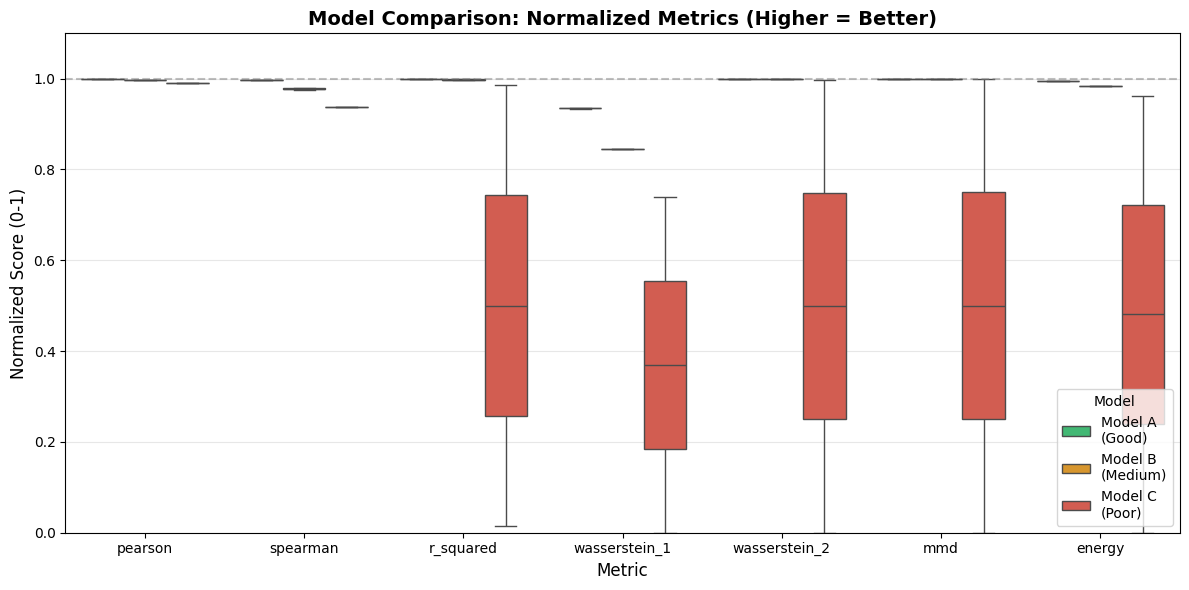

Note: Distance metrics (W1, W2, MMD, Energy) are inverted so higher = better


In [5]:
# Version 1: Normalized boxplots (standardized 0-1 scale)
# Correlation metrics are already 0-1, distance metrics are normalized per metric

fig, ax = plt.subplots(figsize=(12, 6))

# Separate correlation and distance metrics
correlation_metrics = ['pearson', 'spearman', 'r_squared']
distance_metrics = ['wasserstein_1', 'wasserstein_2', 'mmd', 'energy']

# Prepare normalized data
df_norm = df_results.copy()

# For distance metrics, lower is better -> invert and normalize
for metric in distance_metrics:
    mask = df_norm['Metric'] == metric
    values = df_norm.loc[mask, 'Value']
    max_val = values.max()
    if max_val > 0:
        # Invert: 1 - (value / max) so 0 becomes 1 (best) and max becomes 0 (worst)
        df_norm.loc[mask, 'Value'] = 1 - (values / max_val)

sns.boxplot(
    data=df_norm,
    x='Metric',
    y='Value',
    hue='Model',
    palette=['#2ecc71', '#f39c12', '#e74c3c'],  # Green, Orange, Red
    ax=ax,
)

ax.set_title('Model Comparison: Normalized Metrics (Higher = Better)', fontsize=14, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Normalized Score (0-1)', fontsize=12)
ax.legend(title='Model', loc='lower right')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect')

# Add grid
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: Distance metrics (W1, W2, MMD, Energy) are inverted so higher = better")

/var/folders/xd/wg7_d3dd2bd_b5fy87t5hfl00000gq/T/ipykernel_60209/1548336522.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xd/wg7_d3dd2bd_b5fy87t5hfl00000gq/T/ipykernel_60209/1548336522.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)
/var/folders/xd/wg7_d3dd2bd_b5fy87t5hfl00000gq/T/ipykernel_60209/1548336522.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xd/wg7_d3dd2bd_b5fy87t5hfl00000gq/T/ipykernel_60209/1548336522.py:37: UserWarning: set_ticklabels() should only be used with a fixed n

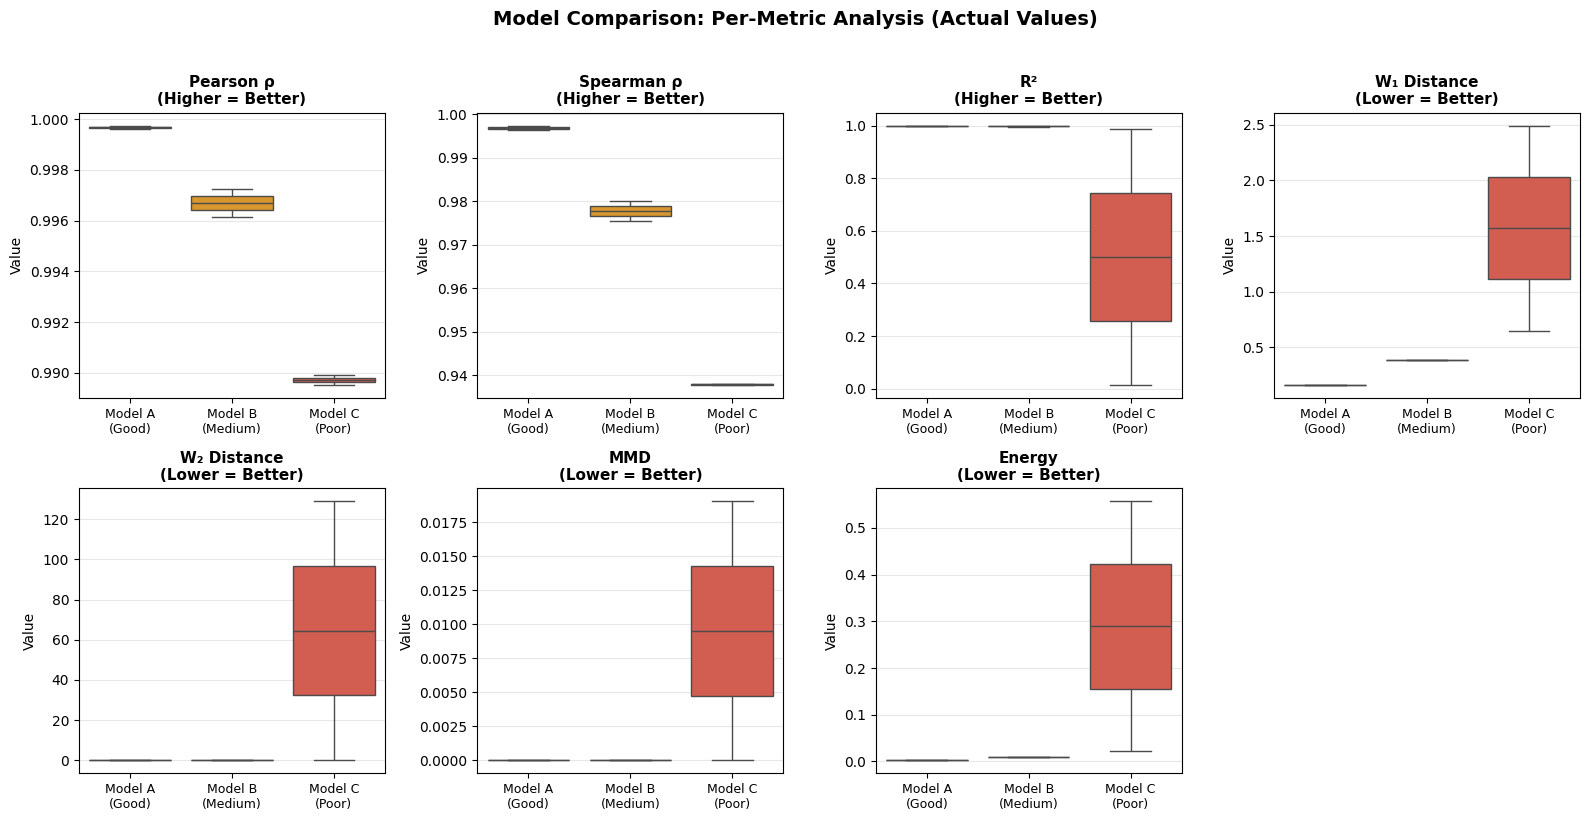

In [6]:
# Version 2: Per-metric boxplots with individual y-axes (actual values)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Metric order and descriptions
metric_info = {
    'pearson': ('Pearson ρ', 'Higher = Better', True),
    'spearman': ('Spearman ρ', 'Higher = Better', True),
    'r_squared': ('R²', 'Higher = Better', True),
    'wasserstein_1': ('W₁ Distance', 'Lower = Better', False),
    'wasserstein_2': ('W₂ Distance', 'Lower = Better', False),
    'mmd': ('MMD', 'Lower = Better', False),
    'energy': ('Energy', 'Lower = Better', False),
}

colors = {'Model A\n(Good)': '#2ecc71', 'Model B\n(Medium)': '#f39c12', 'Model C\n(Poor)': '#e74c3c'}

for idx, (metric, (title, direction, _)) in enumerate(metric_info.items()):
    ax = axes[idx]
    df_metric = df_results[df_results['Metric'] == metric]
    
    sns.boxplot(
        data=df_metric,
        x='Model',
        y='Value',
        palette=colors,
        ax=ax,
    )
    
    ax.set_title(f'{title}\n({direction})', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Value')
    ax.yaxis.grid(True, alpha=0.3)
    
    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)

# Hide unused subplot
axes[-1].axis('off')

fig.suptitle('Model Comparison: Per-Metric Analysis (Actual Values)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Radar Plot: Multi-Metric Overview

Radar plots provide a compact overview of model performance across all metrics.

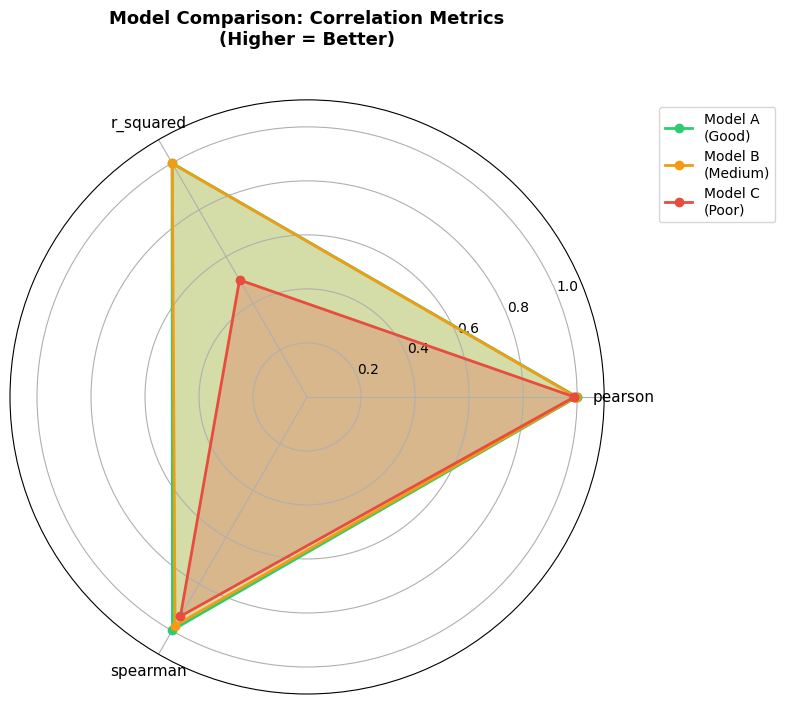

In [7]:
# Create radar plot for model comparison
from matplotlib.patches import Polygon
import numpy as np

# Get average metrics per model (correlation metrics)
metrics_for_radar = ['pearson', 'spearman', 'r_squared']
df_radar = df_results[df_results['Metric'].isin(metrics_for_radar)]
model_means = df_radar.groupby(['Model', 'Metric'])['Value'].mean().unstack()

# Radar plot setup
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

categories = list(model_means.columns)
n_categories = len(categories)
angles = [n / float(n_categories) * 2 * np.pi for n in range(n_categories)]
angles += angles[:1]  # Complete the circle

colors = {'Model A\n(Good)': '#2ecc71', 'Model B\n(Medium)': '#f39c12', 'Model C\n(Poor)': '#e74c3c'}

for model_name in model_means.index:
    values = model_means.loc[model_name].values.tolist()
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[model_name])
    ax.fill(angles, values, alpha=0.25, color=colors[model_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison: Correlation Metrics\n(Higher = Better)', fontsize=13, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

## 6. Bar Chart: Summary View

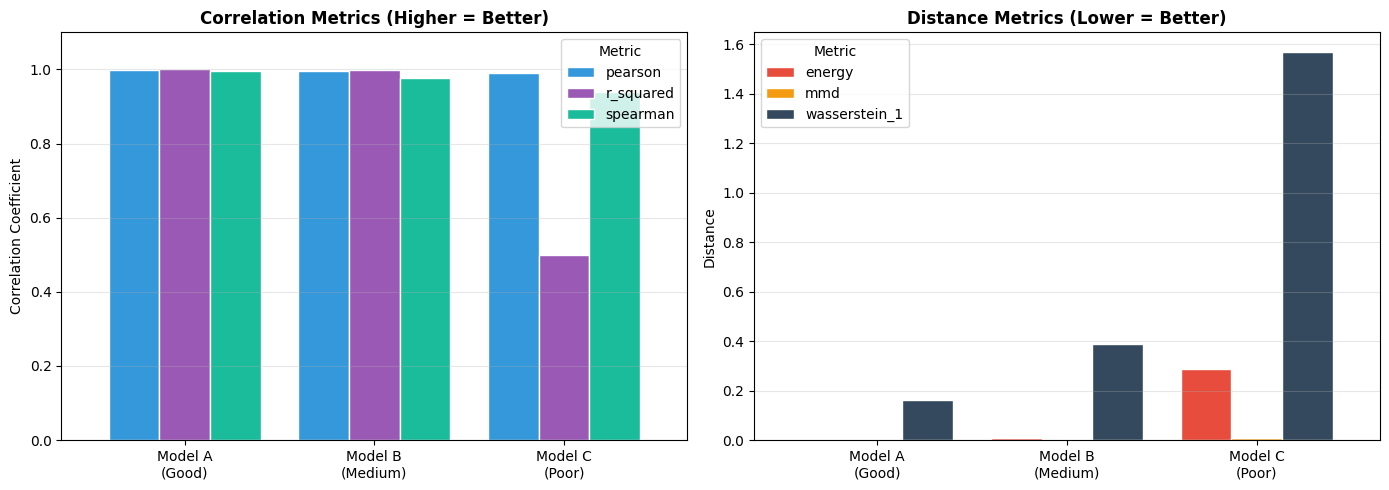

In [8]:
# Summary bar chart - mean metrics across conditions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Correlation metrics (higher = better)
ax1 = axes[0]
corr_df = df_results[df_results['Metric'].isin(['pearson', 'spearman', 'r_squared'])]
corr_means = corr_df.groupby(['Model', 'Metric'])['Value'].mean().unstack()

corr_means.plot(kind='bar', ax=ax1, color=['#3498db', '#9b59b6', '#1abc9c'], width=0.8, edgecolor='white')
ax1.set_title('Correlation Metrics (Higher = Better)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Correlation Coefficient')
ax1.set_xlabel('')
ax1.set_ylim(0, 1.1)
ax1.legend(title='Metric')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.yaxis.grid(True, alpha=0.3)

# Right: Distance metrics (lower = better)
ax2 = axes[1]
dist_df = df_results[df_results['Metric'].isin(['wasserstein_1', 'mmd', 'energy'])]
dist_means = dist_df.groupby(['Model', 'Metric'])['Value'].mean().unstack()

dist_means.plot(kind='bar', ax=ax2, color=['#e74c3c', '#f39c12', '#34495e'], width=0.8, edgecolor='white')
ax2.set_title('Distance Metrics (Lower = Better)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Distance')
ax2.set_xlabel('')
ax2.legend(title='Metric')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Multi-Model Evaluation**: Comparing 3 generative models (Good, Medium, Poor)
2. **Paper Metrics**: Pearson, Spearman, R², Wasserstein-1, Wasserstein-2, MMD, Energy
3. **Visualizations**:
   - **Normalized Boxplots**: All metrics on 0-1 scale (higher = better)
   - **Per-Metric Boxplots**: Actual values with metric-specific y-axes
   - **Radar Plot**: Compact multi-metric overview
   - **Bar Charts**: Summary comparison by metric type

Model rankings (as expected):
- **Model A (Good)**: Highest correlation, lowest distances
- **Model B (Medium)**: Intermediate performance
- **Model C (Poor)**: Lowest correlation, highest distances

For more documentation, see: https://andrearubbi.github.io/GGE/